In [11]:
%pip install pandas
%pip install matplotlib
import sqlite3
import pandas as pd
import numpy as np

# Connect to the database
DB_PATH = 'global.db'
conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.1 MB ? eta -:--:--Downloading matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 24.4 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 24.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 11.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 11.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]
Note: you may need to restart the ker

## Database Schema
Let's first look at what tables exist and their structure.

In [2]:
# List all tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", 
    conn
)
print("Tables in database:")
display(tables)

Tables in database:


,name
0,combinations
1,material_embeddings
2,material_embeddings_chunks
3,material_embeddings_rowids
4,material_embeddings_vector_chunks00
5,materials
6,sqlite_sequence


In [3]:
# Show schema for combinations table
schema = pd.read_sql_query("PRAGMA table_info(combinations)", conn)
print("Combinations table schema:")
display(schema)

Combinations table schema:


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,firstWord,TEXT,1,None,0
2,2,secondWord,TEXT,1,None,0
3,3,resultName,TEXT,1,None,0
4,4,resultEmoji,TEXT,1,None,0
5,5,username,TEXT,1,None,0
6,6,timestamp,TIMESTAMP,1,None,0
7,7,perUserRank,INTEGER,0,None,0
8,8,isDiscovery,BOOLEAN,1,None,0


## Basic Statistics

In [4]:
# Overview stats
query = """
SELECT 
    COUNT(DISTINCT LOWER(resultName)) AS unique_words,
    COUNT(*) AS total_combinations
FROM combinations
"""
pd.read_sql_query(query, conn)

,unique_words,total_combinations
0,4241,9905


In [5]:
# Combinations per user
query = """
SELECT username, COUNT(*) AS combination_count
FROM combinations
GROUP BY username
ORDER BY combination_count DESC
"""
pd.read_sql_query(query, conn)

,username,combination_count
0,isabel,4916
1,tim,2176
2,ace,1378
3,diana,541
4,vann,326
5,tiff,188
6,Connor,179
7,nicole,82
8,sam,41
9,boz,32


## Edge Statistics (Incoming/Outgoing)

## Throw Score Analysis

The "throw score" measures how much each input "throws" toward the result relative to the direction between inputs.

- **Between vector**: embedding from input1 → input2
- **Result vectors**: embeddings from input1 → result and input2 → result  
- **Throw score**: tuple of (cos_sim(result1, between), cos_sim(result2, between))

In [6]:
def get_embedding(word: str) -> np.ndarray:
    """Look up the embedding vector for a word from the materials table."""
    cursor = conn.cursor()
    cursor.execute('SELECT embedding FROM materials WHERE name = ?', (word,))
    result = cursor.fetchone()
    if result is None or result[0] is None:
        return None
    return np.frombuffer(result[0], dtype=np.float32)

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    dot_product = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(dot_product / (norm1 * norm2))

def compute_throw_score(input1: str, input2: str, result: str) -> tuple[float, float] | None:
    """
    Compute the throw score for a combination.
    
    The throw score measures how aligned each input→result vector is 
    with the input1→input2 (between) vector.
    
    Args:
        input1: First input word
        input2: Second input word  
        result: Result word
        
    Returns:
        Tuple of (throw_score_1, throw_score_2) where:
        - throw_score_1 = cos_sim(input1→result, input1→input2)
        - throw_score_2 = cos_sim(input2→result, input1→input2)
        Returns None if any embedding is missing.
    """
    # Get embeddings from database
    emb_input1 = get_embedding(input1)
    emb_input2 = get_embedding(input2)
    emb_result = get_embedding(result)
    
    if emb_input1 is None or emb_input2 is None or emb_result is None:
        return None
    
    # Between vector: input1 → input2
    between_vec = emb_input2 - emb_input1
    
    # Result vectors: input1 → result and input2 → result
    result_vec_1 = emb_result - emb_input1
    result_vec_2 = emb_result - emb_input2
    
    # Compute throw scores (cosine similarities)
    throw_score_1 = abs(cosine_similarity(result_vec_1, between_vec))
    throw_score_2 = abs(cosine_similarity(result_vec_2, between_vec))
    
    return (throw_score_1, throw_score_2)

# Test with an example
example_score = compute_throw_score("Fire", "Water", "Steam")
if example_score:
    print(f"Throw score for Fire + Water = Steam: {example_score}")
    print(f"  Score 1 (Fire→Steam aligned with Fire→Water): {example_score[0]:.4f}")
    print(f"  Score 2 (Water→Steam aligned with Fire→Water): {example_score[1]:.4f}")
else:
    print("Could not compute throw score - missing embeddings")

Throw score for Fire + Water = Steam: (0.5307391881942749, 0.46215587854385376)
  Score 1 (Fire→Steam aligned with Fire→Water): 0.5307
  Score 2 (Water→Steam aligned with Fire→Water): 0.4622


In [7]:
# Compute throw scores for all combinations and analyze statistics
throw_scores = []
combinations_with_scores = []

# Use original case (not LOWER) since materials table has case-sensitive names
query = "SELECT firstWord, secondWord, resultName FROM combinations WHERE firstWord != secondWord"
combinations_df = pd.read_sql_query(query, conn)

for _, row in combinations_df.iterrows():
    score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
    if score:
        throw_score = max(score)  # Take the larger of the two scores
        throw_scores.append(throw_score)
        combinations_with_scores.append({
            'firstWord': row['firstWord'],
            'secondWord': row['secondWord'],
            'resultName': row['resultName'],
            'throw_score': throw_score
        })

print(f"Total combinations analyzed: {len(throw_scores)}")
print(f"\nThrow Score Statistics:")
print(f"  Smallest: {min(throw_scores):.4f}")
print(f"  Largest: {max(throw_scores):.4f}")
print(f"  Mean: {np.mean(throw_scores):.4f}")
print(f"  Median: {np.median(throw_scores):.4f}")

# Find combinations with min and max scores
scores_df = pd.DataFrame(combinations_with_scores)

# Min score combination
min_idx = scores_df['throw_score'].idxmin()
min_row = scores_df.loc[min_idx]
print(f"\nCombination with SMALLEST throw score:")
print(f"  {min_row['firstWord']} + {min_row['secondWord']} = {min_row['resultName']}")
print(f"  Score: {min_row['throw_score']:.4f}")

# Max score combination
max_idx = scores_df['throw_score'].idxmax()
max_row = scores_df.loc[max_idx]
print(f"\nCombination with LARGEST throw score:")
print(f"  {max_row['firstWord']} + {max_row['secondWord']} = {max_row['resultName']}")
print(f"  Score: {max_row['throw_score']:.4f}")

Total combinations analyzed: 5824

Throw Score Statistics:
  Smallest: 0.2466
  Largest: 1.0000
  Mean: 0.6191
  Median: 0.6049

Combination with SMALLEST throw score:
  Docker + Dock = Shipyard
  Score: 0.2466

Combination with LARGEST throw score:
  Legend + L = Legend
  Score: 1.0000


In [8]:
# Calculate average throw score per word (as either firstWord or secondWord)
word_scores = {}
word_examples = {}  # Store example combinations for each word

for combo in combinations_with_scores:
    for word in [combo['firstWord'], combo['secondWord']]:
        if word not in word_scores:
            word_scores[word] = []
            word_examples[word] = []
        word_scores[word].append(combo['throw_score'])
        word_examples[word].append({
            'combo': f"{combo['firstWord']} + {combo['secondWord']} = {combo['resultName']}",
            'score': combo['throw_score']
        })

# Compute averages and include examples
word_avg_scores = []
for word, scores in word_scores.items():
    # Get up to 3 examples, sorted by score
    examples = sorted(word_examples[word], key=lambda x: x['score'])
    example_strs = [f"{e['combo']} ({e['score']:.3f})" for e in examples[:3]]
    
    word_avg_scores.append({
        'word': word,
        'avg_throw_score': np.mean(scores),
        'num_combinations': len(scores),
        'examples': ' | '.join(example_strs)
    })

word_avg_df = pd.DataFrame(word_avg_scores).sort_values('avg_throw_score')

# Filter by minimum usage count
K = 5
word_avg_df_filtered = word_avg_df[word_avg_df['num_combinations'] >= K]

N = 20

print(f"Top {N} words with LOWEST average throw score (used at least {K} times):")
display(word_avg_df_filtered.head(N))

print(f"\nTop {N} words with HIGHEST average throw score (used at least {K} times):")
display(word_avg_df_filtered.tail(N).iloc[::-1])

Top 20 words with LOWEST average throw score (used at least 5 times):


,word,avg_throw_score,num_combinations,examples
1899,Pushover,0.516285,5,Cowardlypervert + Pushover = Doormat (0.474) |...
1768,Soulmate,0.518943,6,Soulmate + Soulmates = Love (0.249) | Soulmate...
393,Kagamiku,0.520294,6,Kagamiku + Yuri = Love (0.440) | Rinlen + Kaga...
914,Schizophrenia,0.529848,5,Schizophrenia + Psychosis = Madness (0.373) | ...
526,Idol,0.536994,9,Kpop + Idol = Bts (0.491) | Idol + Hentai = Ec...
803,Femmefatale,0.537082,6,Dominatrix + Femmefatale = Seductress (0.412) ...
1490,Pornstar,0.538531,5,Pussywhip + Pornstar = Bdsm (0.459) | Pussywhi...
842,Dock,0.539349,8,Docker + Dock = Shipyard (0.247) | Repository ...
2120,Perversion,0.542680,18,Pervert + Perversion = Degeneracy (0.440) | Pe...
2229,Dataloss,0.543793,6,Dataloss + Storage = Corruption (0.452) | Raid...



Top 20 words with HIGHEST average throw score (used at least 5 times):


,word,avg_throw_score,num_combinations,examples
253,Reboot,0.801408,6,Quadruplets + Reboot = Rebirth (0.590) | Reboo...
2350,Reactapp,0.783031,6,Revival + Reactapp = Reboot (0.594) | Reactapp...
1029,Liberation,0.765966,8,Galaxy + Liberation = Freedom Space (0.674) | ...
576,Legend,0.761484,8,Legend + Geology = Mythstone (0.614) | Opensou...
469,Fungus,0.751449,8,Fungus + Catgirl = Morel Neko (0.557) | Fungus...
790,Neko,0.748497,23,Nekomimi + Neko = Catgirl (0.310) | Neko + Nek...
923,Disaster,0.747018,12,Harddrive + Disaster = Dataloss (0.535) | Nato...
466,Mold,0.742123,13,Fog + Mold = Mildew (0.628) | Mold + Alligator...
1182,Wedding,0.737433,6,Wedding + Opensource = Openlove (0.635) | Wedd...
169,Malware,0.726444,15,Pandemic + Malware = Cyberplague (0.527) | Mal...


In [9]:
# Word usage analysis
query = """
WITH word_usage AS (
  SELECT 
    word,
    SUM(used_as_input) AS incoming_edges,
    SUM(used_as_result) AS outgoing_edges
  FROM (
    SELECT LOWER(firstWord) AS word, 1 AS used_as_input, 0 AS used_as_result FROM combinations
    UNION ALL
    SELECT LOWER(secondWord) AS word, 1 AS used_as_input, 0 AS used_as_result FROM combinations
    UNION ALL
    SELECT LOWER(resultName) AS word, 0 AS used_as_input, 1 AS used_as_result FROM combinations
  )
  GROUP BY word
)
SELECT 
  ROUND(AVG(incoming_edges), 2) AS avg_incoming,
  ROUND(AVG(outgoing_edges), 2) AS avg_outgoing
FROM word_usage
"""
pd.read_sql_query(query, conn)

,avg_incoming,avg_outgoing
0,4.67,2.33


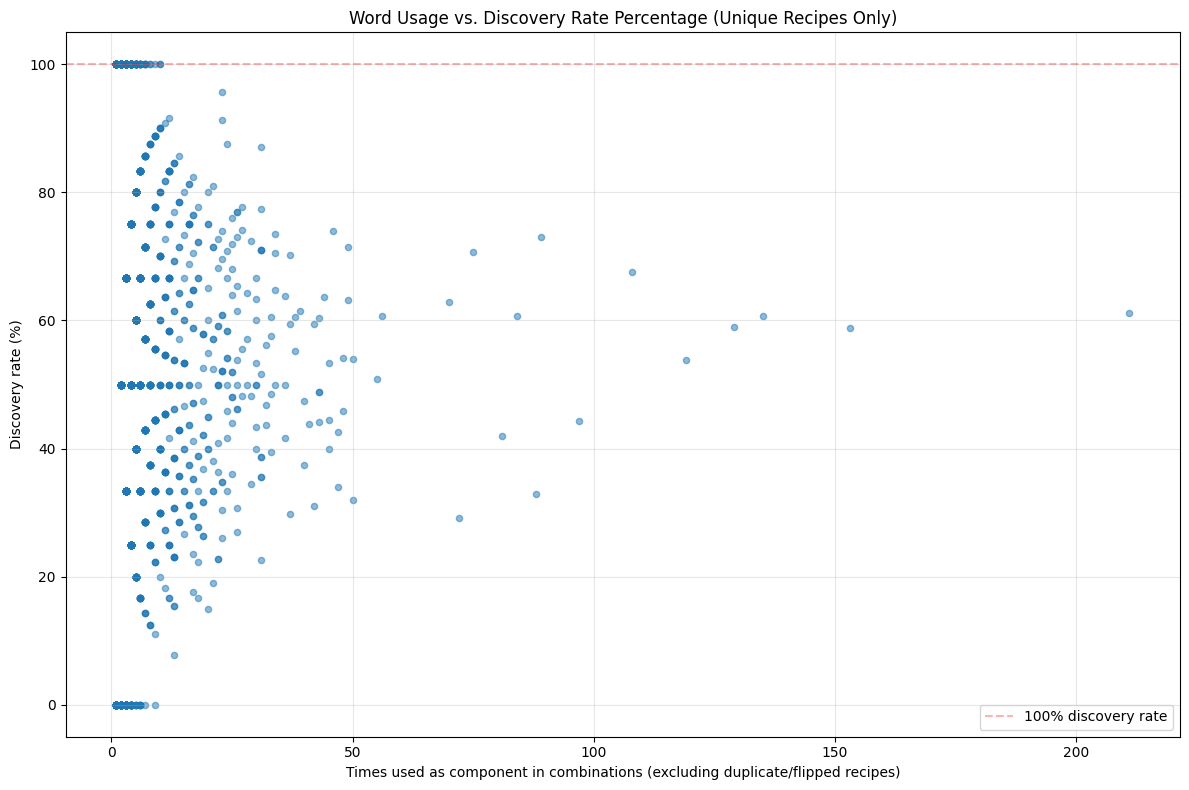

Total words analyzed: 4122
Total unique recipes: 9068
X range: 1 to 211
Y range: 0.00% to 100.00%


In [ ]:
import matplotlib.pyplot as plt

# For each word, count:
# X = times used as component (firstWord or secondWord)
# Y = average throw score of the word
# Skip duplicate/flipped recipes

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

word_stats = {}
seen_recipes_global = set()  # Track all normalized recipes we've seen

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

for _, row in combos.iterrows():
    # Get normalized recipe to detect flipped combinations
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
    
    # Skip if we've already seen this recipe (or its flip)
    if normalized in seen_recipes_global:
        continue
    seen_recipes_global.add(normalized)
    
    # Compute throw score for this combination
    score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
    if score:
        throw_score = max(score)
    else:
        throw_score = 0.0
    
    # Track stats for both input words
    for word in [row['firstWord'], row['secondWord']]:
        if word not in word_stats:
            word_stats[word] = {'used': 0, 'throw_scores': []}
        
        word_stats[word]['used'] += 1
        word_stats[word]['throw_scores'].append(throw_score)

# Create scatter plot data with average throw scores
x_vals = [stats['used'] for stats in word_stats.values()]
y_vals = [np.mean(stats['throw_scores']) if stats['throw_scores'] else 0.0 
          for stats in word_stats.values()]
words = list(word_stats.keys())

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(x_vals, y_vals, alpha=0.5, s=20)
plt.xlabel('Times used as component in combinations (excluding duplicate/flipped recipes)')
plt.ylabel('Average throw score')
plt.title('Word Usage vs. Average Throw Score (Unique Recipes Only)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total words analyzed: {len(word_stats)}")
print(f"Total unique recipes: {len(seen_recipes_global)}")
print(f"X range: {min(x_vals)} to {max(x_vals)}")
print(f"Y range: {min(y_vals):.4f} to {max(y_vals):.4f}")

Top 4 users: ['isabel', 'tim', 'ace', 'diana']


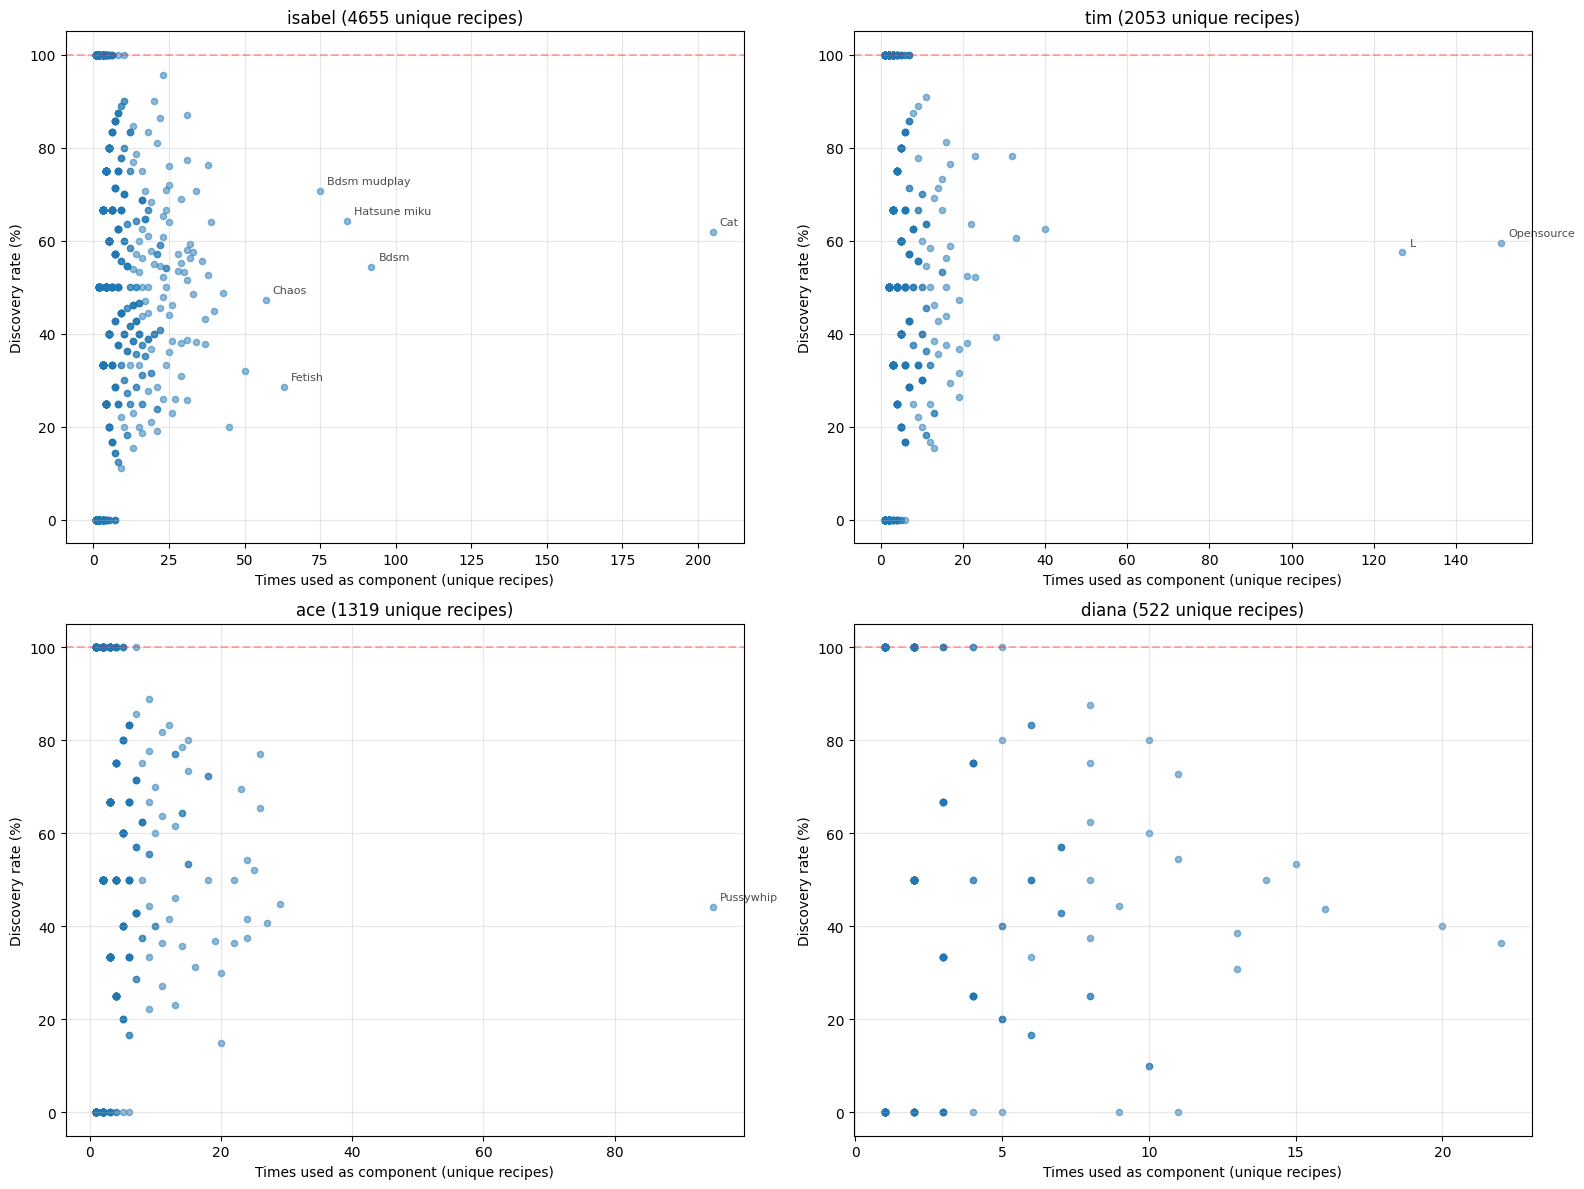


isabel: 4916 total combinations, 4655 unique recipes

tim: 2176 total combinations, 2053 unique recipes

ace: 1378 total combinations, 1319 unique recipes

diana: 541 total combinations, 522 unique recipes


In [ ]:
import matplotlib.pyplot as plt

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Get top 4 users by number of combinations
top_users_query = """
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT 4
"""
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

print(f"Top 4 users: {top_users}")

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Create subplots for each user
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, username in enumerate(top_users):
    ax = axes[idx]
    
    # Filter combinations for this user
    user_combos = combos[combos['username'] == username]
    
    word_stats = {}
    seen_recipes_user = set()  # Track normalized recipes for this user
    
    for _, row in user_combos.iterrows():
        # Get normalized recipe to detect flipped combinations
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
        
        # Skip if we've already seen this recipe (or its flip) for this user
        if normalized in seen_recipes_user:
            continue
        seen_recipes_user.add(normalized)
        
        # Compute throw score for this combination
        score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
        if score:
            throw_score = max(score)
        else:
            throw_score = 0.0
        
        # Track stats for both input words
        for word in [row['firstWord'], row['secondWord']]:
            if row['firstWord'] == row['secondWord']:  # Skip same-component combos
                continue
                
            if word not in word_stats:
                word_stats[word] = {'used': 0, 'throw_scores': []}
            
            word_stats[word]['used'] += 1
            word_stats[word]['throw_scores'].append(throw_score)
    
    # Create scatter plot data with average throw scores
    words = list(word_stats.keys())
    x_vals = [stats['used'] for stats in word_stats.values()]
    y_vals = [np.mean(stats['throw_scores']) if stats['throw_scores'] else 0.0 
              for stats in word_stats.values()]
    
    # Plot
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    
    # Label outlier words (used more than 50 times)
    for i, (word, x, y) in enumerate(zip(words, x_vals, y_vals)):
        if x > 50:
            ax.annotate(word, (x, y), fontsize=8, alpha=0.7, 
                       xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Times used as component (unique recipes)')
    ax.set_ylabel('Average throw score')
    ax.set_title(f'{username} ({len(seen_recipes_user)} unique recipes)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for each user
for username in top_users:
    user_combos = combos[combos['username'] == username]
    seen_recipes_user = set()
    for _, row in user_combos.iterrows():
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
        seen_recipes_user.add(normalized)
    print(f"\n{username}: {len(user_combos)} total combinations, {len(seen_recipes_user)} unique recipes")

In [22]:
# Analyze all combinations for a specific word
WORD_TO_ANALYZE = "L"  # Change this to analyze different words

# Get ALL combinations ordered by id to properly track discoveries
all_combos = pd.read_sql_query("""
    SELECT id, firstWord, secondWord, resultName, username
    FROM combinations
    ORDER BY id
""", conn)

# Helper function to normalize recipe (canonical form: lower ingredient alphabetically)
def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Track what each user has discovered and how they discovered it
user_discovered_so_far = {}  # username -> {normalized_recipe: (discovery_combo, result)}
user_seen_recipes = {}  # username -> set of normalized recipes they've seen
results = []

for _, row in all_combos.iterrows():
    username = row['username']
    result = row['resultName']
    combo_str = f"{row['firstWord']} + {row['secondWord']} = {result}"
    
    # Initialize user tracking
    if username not in user_discovered_so_far:
        user_discovered_so_far[username] = {}
        user_seen_recipes[username] = set()
    
    # Get normalized recipe to detect flipped combos
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
    
    # Check if this combination uses our word
    uses_word = (row['firstWord'] == WORD_TO_ANALYZE or row['secondWord'] == WORD_TO_ANALYZE)
    
    # Only count if this user hasn't seen this exact recipe (or its flip) before
    if uses_word and normalized not in user_seen_recipes[username]:
        # Check if this result was already discovered by this user via any recipe
        was_discovery = result not in user_discovered_so_far[username]
        
        discovery_combo = None
        if not was_discovery:
            # Get the original discovery combination for this result
            discovery_combo = user_discovered_so_far[username][result]
        
        results.append({
            'id': row['id'],
            'combination': combo_str,
            'username': username,
            'was_discovery': '✓' if was_discovery else '✗',
            'discovery_combo': discovery_combo if discovery_combo else '-'
        })
    
    # Track this recipe and result for the user (for ALL combinations)
    user_seen_recipes[username].add(normalized)
    if result not in user_discovered_so_far[username]:
        user_discovered_so_far[username][result] = combo_str

if len(results) == 0:
    print(f"No combinations found for word: {WORD_TO_ANALYZE}")
else:
    print(f"Found {len(results)} combinations using '{WORD_TO_ANALYZE}' (excluding duplicate/flipped recipes)")
    print()
    
    # Display as DataFrame
    results_df = pd.DataFrame(results)
    display(results_df)
    
    # Summary statistics
    total_discoveries = len([r for r in results if r['was_discovery'] == '✓'])
    discovery_rate = (total_discoveries / len(results) * 100) if len(results) > 0 else 0
    
    print(f"\nSummary for '{WORD_TO_ANALYZE}':")
    print(f"  Total unique recipes: {len(results)}")
    print(f"  Discoveries: {total_discoveries}")
    print(f"  Discovery rate: {discovery_rate:.1f}%")

Found 128 combinations using 'L' (excluding duplicate/flipped recipes)



,id,combination,username,was_discovery,discovery_combo
0,4509,L + L = Llama,tim,✓,-
1,4511,Tapestry + L = Landscape,tim,✓,-
2,4512,Fury + L = Hurricane,tim,✗,Storm + Ocean = Hurricane
3,4513,L + Opera whip = Lasso,tim,✓,-
4,4514,L + Bohemian rhapsody = Queen,tim,✓,-
...,...,...,...,...,...
123,8208,Opencontainer + L = Bottle,tim,✓,-
124,9264,L + Nostalgia = Longing,tim,✓,-
125,9475,Nothing + L = Void,tim,✗,Oblivion + Oblivion = Void
126,9591,Learning + L = Literacy,tim,✓,-



Summary for 'L':
  Total unique recipes: 128
  Discoveries: 74
  Discovery rate: 57.8%


In [ ]:
# Top words by incoming edges (most used as inputs)
query = """
WITH word_usage AS (
  SELECT 
    word,
    SUM(used_as_input) AS incoming_edges
  FROM (
    SELECT LOWER(firstWord) AS word, 1 AS used_as_input FROM combinations
    UNION ALL
    SELECT LOWER(secondWord) AS word, 1 AS used_as_input FROM combinations
  )
  GROUP BY word
)
SELECT word, incoming_edges
FROM word_usage
ORDER BY incoming_edges DESC
LIMIT 20
"""
pd.read_sql_query(query, conn)

,word,incoming_edges
0,cat,237
1,earth,223
2,fire,157
3,opensource,156
4,l,155
5,water,144
6,bdsm,139
7,air,135
8,pussywhip,116
9,hatsune miku,115


## Sample Data

In [ ]:
# View recent combinations
query = """
SELECT * FROM combinations
ORDER BY id DESC
LIMIT 20
"""
pd.read_sql_query(query, conn)

,id,firstWord,secondWord,resultName,resultEmoji,username,timestamp,perUserRank,isDiscovery
0,9905,Dirt,Mist,Mud,🌿,boz,2026-01-10T15:30:31.027032,3,0
1,9904,Air,Mud,Mist,❄,boz,2026-01-10T15:30:21.086555,2,0
2,9903,Fog,Spring,Mist,❄,boz,2026-01-10T15:30:04.982005,5,0
3,9902,Warm breeze,Earth,Spring,💧,boz,2026-01-10T15:29:57.585875,4,0
4,9901,Geyser,Mist,Fog,❄,boz,2026-01-10T15:29:49.143170,4,0
5,9900,Mud,Warm breeze,Mist,❄,boz,2026-01-10T15:29:42.184121,4,0
6,9899,Warm breeze,Steam,Sauna,🧖,boz,2026-01-10T15:29:25.753218,4,1
7,9898,Smoke,Geyser,Steam,💧,boz,2026-01-10T15:29:24.301275,4,0
8,9897,Steam,Geothermal,Geyser,♨,boz,2026-01-10T15:29:22.685475,3,0
9,9896,Rickandmorty,Robot chicken,Adult Cartoon,📺,tim,2026-01-10T05:25:43.398373,224,1


## Custom Query
Write your own SQL query below:

In [ ]:
# Your custom query here
custom_query = """
SELECT * FROM combinations LIMIT 5
"""
pd.read_sql_query(custom_query, conn)

,id,firstWord,secondWord,resultName,resultEmoji,username,timestamp,perUserRank,isDiscovery
0,1,Fire,Water,Steam,💧,njj,2026-01-04T20:13:46.177126,1,1
1,2,Air,Air,Breeze,💨,njj,2026-01-04T20:13:49.231727,1,1
2,3,Water,Fire,Steam,💧,shm,2026-01-05T23:47:51.956799,1,0
3,4,Fire,Air,Flame,🔥,shm,2026-01-05T23:52:01.184969,1,1
4,5,Earth,Flame,Lava,🌋,shm,2026-01-05T23:52:25.560854,2,1


In [ ]:
# Close connection when done
# conn.close()
# print("Connection closed")